In [1]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import KFold, cross_val_score

from scipy.stats import spearmanr, pearsonr
from statsmodels.stats.multitest import multipletests

In [2]:
with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/sim44_new.pkl", "rb") as f:
    all_results = pickle.load(f)

with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/mc_measures1.4.pkl", "rb") as f:
    mc_measures = pickle.load(f)

In [3]:
print(all_results.keys())
print(all_results[1][2222].keys())
print(mc_measures.keys())

dict_keys([14, 1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 15, 17, 18, 22, 23, 24, 27, 28, 29, 30, 33, 35, 36, 38, 39, 40, 41, 42, 43, 45, 47, 49])
dict_keys(['raw_score', 'lenweighted_score', 'reward_min', 'len'])
dict_keys(['tau_orth_vec', 'tau_orth_vec_not_norm', 'orth_vec_thresh_crossed', 'orth_vec_thresh_crossed_not_norm', 'norm_thresh_crossed', 'summed_MC_svd', 'MC_singular_components_svd', 'MC_singular_components_hs_svd', 'participation_ratio_svd'])


In [4]:
weight_trials = [1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 17, 18, 22, 23, 24, 27, 28, 29, 30, 33, 35, 36, 38, 39, 40, 41, 42, 43, 45, 47, 49]
n_seeds = 3
seeds = [1111, 2222, 3333]
n_policies = 4

sorted_weight_trials = sorted(weight_trials)

time_interval = [80000000,100000000]

In [5]:
'''
data structure all_results:
dictionary with all weight trials with dictionary with the seeds as keys
{2222:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
                3333:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
                4444:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None},
                5555:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}}
'''

"\ndata structure all_results:\ndictionary with all weight trials with dictionary with the seeds as keys\n{2222:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, \n                3333:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, \n                4444:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None},\n                5555:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}}\n"

In [6]:

mean_results = dict()

for trial in weight_trials:
    mean_results_by_seeds = {1111:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
                2222:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
                3333:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}}
    for seed in seeds:
        mean_results_by_seeds[seed]['raw_score'] = all_results[trial][seed]['raw_score'].mean(axis=1)
        mean_results_by_seeds[seed]['lenweighted_score'] = all_results[trial][seed]['lenweighted_score'].mean(axis=1)
        mean_results_by_seeds[seed]['reward_min'] = all_results[trial][seed]['reward_min'].mean(axis=1)
        mean_results_by_seeds[seed]['len'] = all_results[trial][seed]['len'].mean(axis=1)
    mean_results[trial] = mean_results_by_seeds
    



In [7]:
print(mean_results[1][1111]['raw_score'].to_list())
print(len(mean_results[1][seed]['raw_score'].index.to_list()))

[0.6, 0.575, 0.55, 0.5375000000000001, 0.49583333333333335, 0.475, 0.4625, 0.475, 0.475, 0.48749999999999993, 0.49999999999999994, 0.5, 0.525, 0.5083333333333333, 0.5, 0.44166666666666665, 0.5, 0.4375, 0.425, 0.4125, 0.39999999999999997, 0.38750000000000007, 0.375, 0.4, 0.4625, 0.42500000000000004, 0.42500000000000004, 0.4625, 0.475, 0.5125000000000001, 0.5, 0.5, 0.5, 0.47500000000000003, 0.4625, 0.5375, 0.5625, 0.55, 0.575, 0.575, 0.625, 0.6125, 0.625, 0.6499999999999999, 0.7125, 0.7, 0.7, 0.7, 0.6875, 0.675, 0.6375, 0.5875, 0.575, 0.5625, 0.55, 0.55, 0.5875, 0.6625000000000001, 0.7375, 0.7, 0.75, 0.7625, 0.7875, 0.8125, 0.79375, 0.75, 0.69375, 0.6875, 0.7250000000000001, 0.7749999999999999, 0.8, 0.9, 0.8875000000000001, 0.9125, 0.875, 0.9541666666666666, 1.075, 1.0625, 1.025, 1.025, 1.05, 1.025, 1.0750000000000002, 1.1, 1.1104166666666666, 1.1125, 1.1624999999999999, 1.175, 1.175, 1.1833333333333333, 1.1916666666666667, 1.1666666666666665, 1.1666666666666665, 1.23125, 1.3125, 1.27500

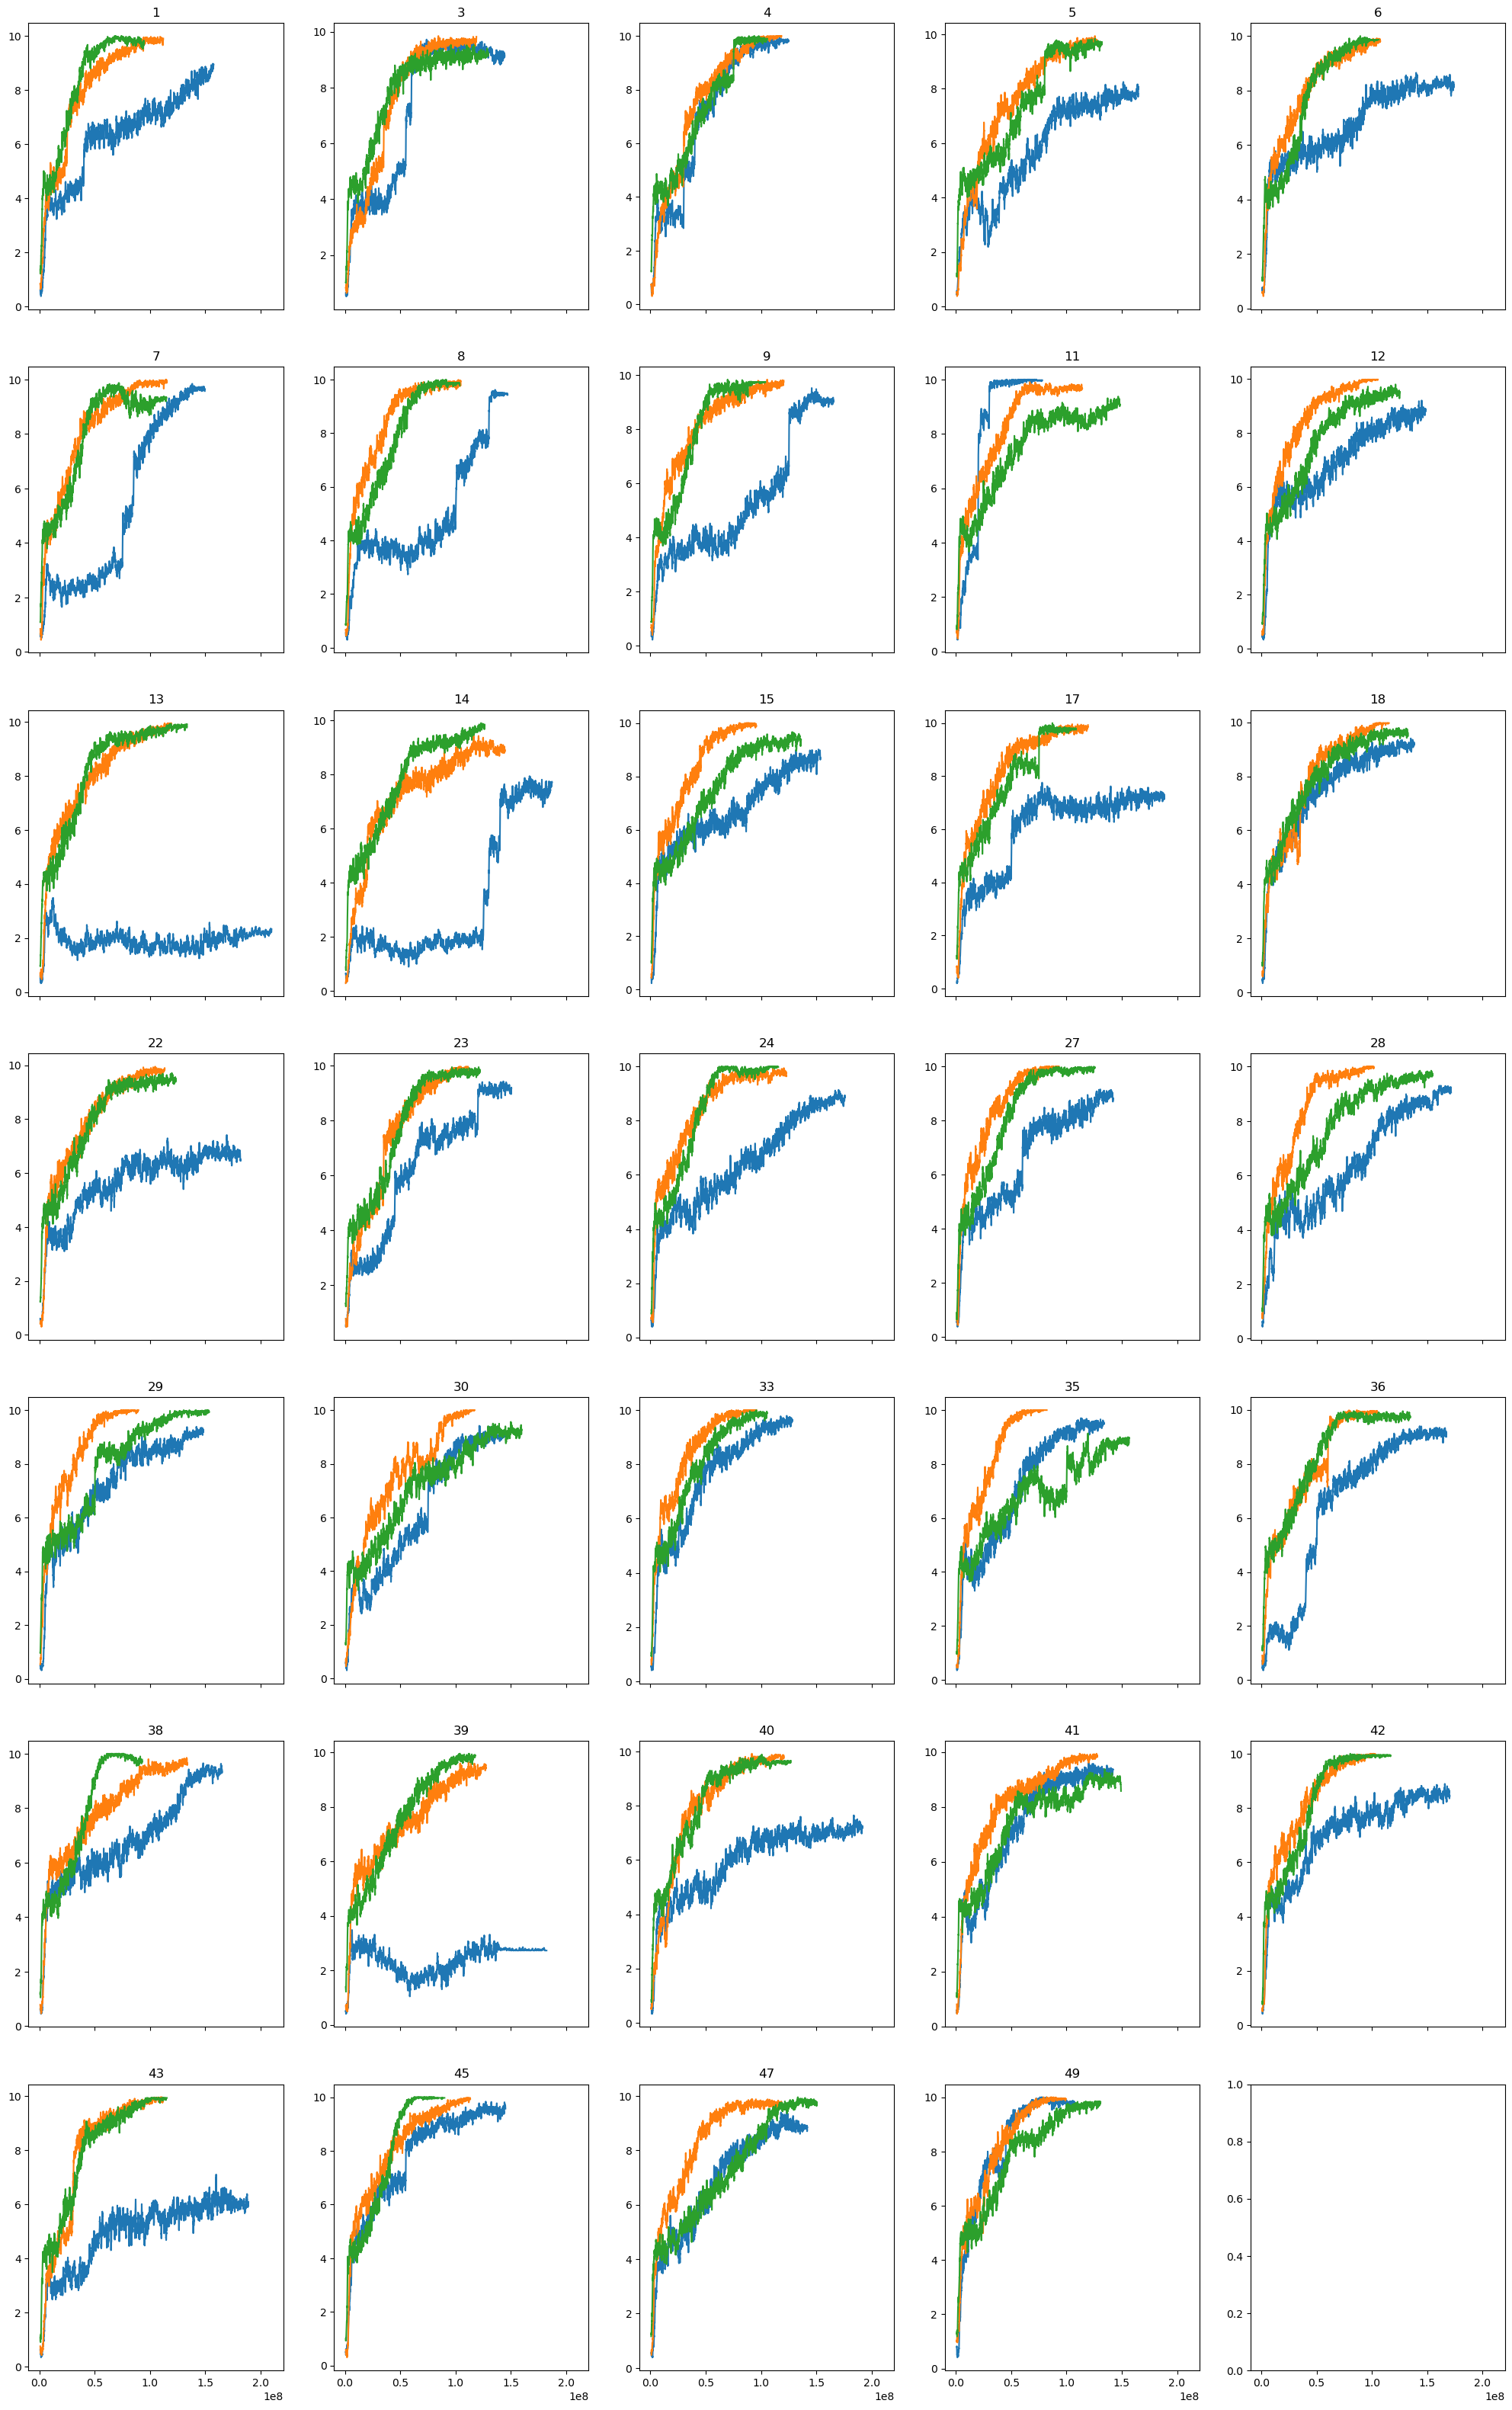

In [8]:
# plot the raw score curves for all weight trials & policies
'''
fig, ax = plt.subplots(7,5, figsize=(25,40), sharex=True)
for i,t in enumerate(weight_trials):
    for policy in range(n_policies):
        raw_score = mean_results[t][policy][f'{policy}/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score']
        idx = all_results[t][policy].index.to_list()
        ax[i//5, i%5].plot(idx, raw_score)
        ax[i//5, i%5].set_title(f'{t}')
'''

fig, ax = plt.subplots(7,5, figsize=(25,40), sharex=True)
for i,t in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        raw_score = mean_results[t][seed]['raw_score']
        idx = mean_results[t][seed]['raw_score'].index.to_list()
        ax[i//5, i%5].plot(idx, raw_score)
        ax[i//5, i%5].set_title(f'{t}')

In [9]:
# take the mean of a metric for the relevant time interval
# mean raw score time inverval has the format (trial,seed)
mean_raw_score_time_interval = dict()
for i, trial in enumerate(weight_trials):
    mean_raw_score_time_interval[trial] = dict()
    for seed in seeds:
        raw_score = mean_results[trial][seed]['raw_score']
        raw_score_time_interval = raw_score[time_interval[0]:time_interval[1]]
        mean_raw_score_time_interval[trial][seed] = raw_score_time_interval.mean()

/tmp/ipykernel_766089/335904163.py:8: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  raw_score_time_interval = raw_score[time_interval[0]:time_interval[1]]


In [10]:
print(mean_raw_score_time_interval[1].keys())
print(mean_raw_score_time_interval[1][2222])

dict_keys([1111, 2222, 3333])
9.682319118881619


#### homemade MC measures

In [11]:
print(mc_measures.keys())

dict_keys(['tau_orth_vec', 'tau_orth_vec_not_norm', 'orth_vec_thresh_crossed', 'orth_vec_thresh_crossed_not_norm', 'norm_thresh_crossed', 'summed_MC_svd', 'MC_singular_components_svd', 'MC_singular_components_hs_svd', 'participation_ratio_svd'])


In [12]:
print(mc_measures['orth_vec_thresh_crossed'])
print(mean_raw_score_time_interval)

[28. 27. 27. 20. 18. 18. 39. 28. 28. 27. 14. 50. 26. 25. 30. 29. 50. 15.
 14. 17. 12. 13. 24. 21. 17. 26. 50. 23. 20. 14. 19. 41. 15. 21.]
{1: {1111: np.float64(6.898100324837582), 2222: np.float64(9.682319118881619), 3333: np.float64(9.801094546043524)}, 3: {1111: np.float64(9.428240091263891), 2222: np.float64(9.582089659986025), 3333: np.float64(9.095292547178792)}, 4: {1111: np.float64(9.53303749910759), 2222: np.float64(9.642949487107096), 3333: np.float64(9.858076701638359)}, 5: {1111: np.float64(6.949563968015992), 2222: np.float64(9.28929940364067), 3333: np.float64(9.432750181685714)}, 6: {1111: np.float64(7.071264367816092), 2222: np.float64(9.59307621892517), 3333: np.float64(9.785785414922408)}, 7: {1111: np.float64(6.763374339615907), 2222: np.float64(9.778227389281549), 3333: np.float64(9.089793853073463)}, 8: {1111: np.float64(4.463050974512743), 2222: np.float64(9.791051412613912), 3333: np.float64(9.856677583827135)}, 9: {1111: np.float64(5.08240379810095), 2222: np.fl

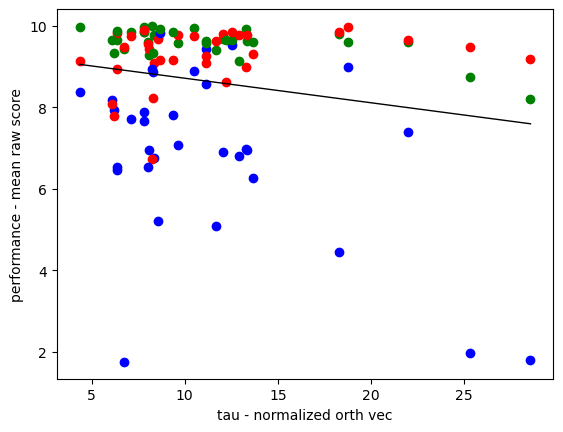

In [13]:
colors = ['b', 'g', 'r']

seeds=[1111,2222, 3333]

plt.figure()
#plt.scatter(mc_measures['orth_vec_thresh_crossed'], mean_raw_score_time_interval, c='b')
for i,trial in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        plt.scatter(mc_measures['tau_orth_vec'][i], mean_raw_score_time_interval[trial][seed], c=colors[j])
plt.xlabel('tau - normalized orth vec')
plt.ylabel('performance - mean raw score')

# fit a linear regression
x, y = [], []
for i, trial in enumerate(weight_trials):
    for seed in seeds:
        x.append(mc_measures['tau_orth_vec'][i])
        y.append(mean_raw_score_time_interval[trial][seed])

x = np.asarray(x, float)
y = np.asarray(y, float)
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

reg = LinearRegression().fit(x.reshape(-1, 1), y)
x = np.linspace(x.min(), x.max(), 200)
plt.plot(x, reg.coef_[0]*x + reg.intercept_, color='black', linewidth=1)

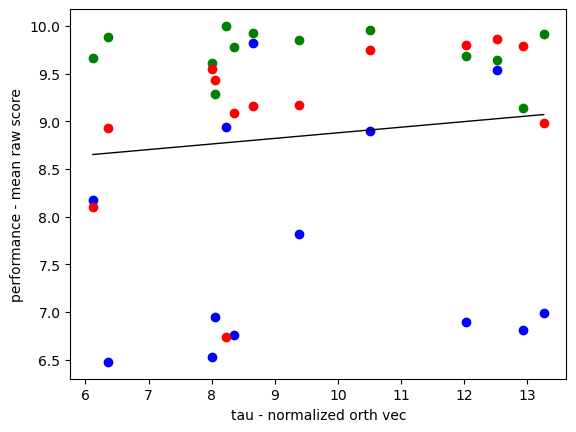

In [14]:
plt.figure()
#plt.scatter(mc_measures['orth_vec_thresh_crossed'], mean_raw_score_time_interval, c='b')
for i,trial in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        if mc_measures['tau_orth_vec_not_norm'][i] >4:
            plt.scatter(mc_measures['tau_orth_vec'][i], mean_raw_score_time_interval[trial][seed], c=colors[j])
plt.xlabel('tau - normalized orth vec')
plt.ylabel('performance - mean raw score')

# fit a linear regression
x, y = [], []
for i, trial in enumerate(weight_trials):
    if mc_measures['tau_orth_vec_not_norm'][i] >4:
        for seed in seeds:
            x.append(mc_measures['tau_orth_vec'][i])
            y.append(mean_raw_score_time_interval[trial][seed])

x = np.asarray(x, float)
y = np.asarray(y, float)
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

reg = LinearRegression().fit(x.reshape(-1, 1), y)
x = np.linspace(x.min(), x.max(), 200)
plt.plot(x, reg.coef_[0]*x + reg.intercept_, color='black', linewidth=1)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33]
34
34


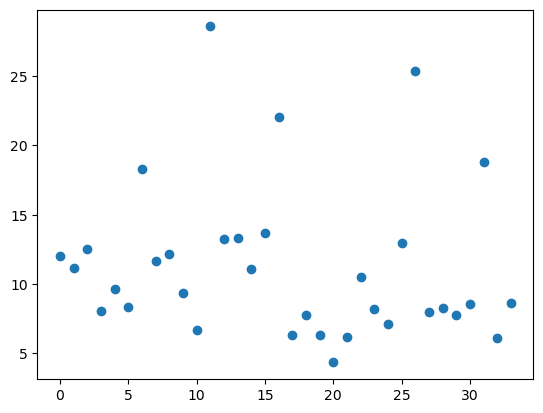

In [15]:
plt.figure()
x_vals = np.arange(34)
print(x_vals)
print(len(x_vals))
print(len(mc_measures['tau_orth_vec']))
plt.scatter(x_vals,mc_measures['tau_orth_vec'])

Text(0, 0.5, 'tau - orth vec')

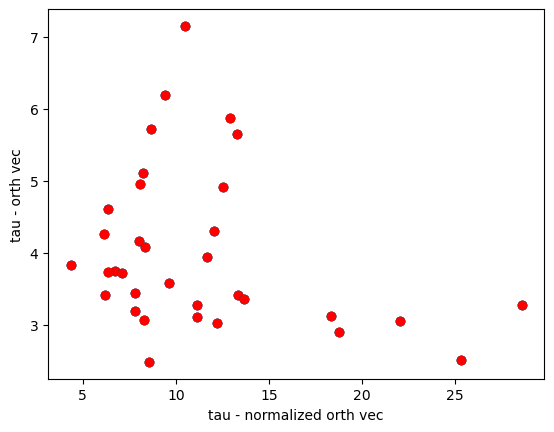

In [16]:
plt.figure()
#plt.scatter(mc_measures['orth_vec_thresh_crossed'], mean_raw_score_time_interval, c='b')
for i,trial in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        plt.scatter(mc_measures['tau_orth_vec'][i], mc_measures['tau_orth_vec_not_norm'][i], c=colors[j])
plt.xlabel('tau - normalized orth vec')
plt.ylabel('tau - orth vec')

Text(0.5, 1.0, 'relation between the subspace normalized and the normalized subspace measure')

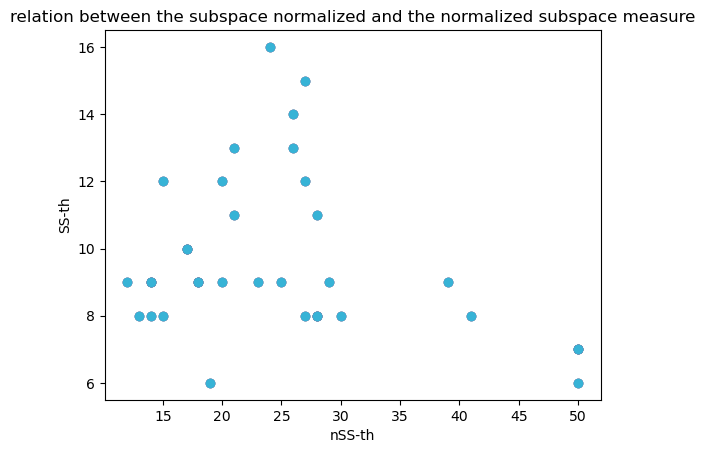

In [30]:
colors = ["#549268", '#a956b7', "#37B3D6"]

plt.figure()
#plt.scatter(mc_measures['orth_vec_thresh_crossed'], mean_raw_score_time_interval, c='b')
for i,trial in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        plt.scatter(mc_measures['orth_vec_thresh_crossed'][i], mc_measures['orth_vec_thresh_crossed_not_norm'][i], c=colors[j])
plt.xlabel('nSS-th')
plt.ylabel('SS-th')
plt.title('relation between the subspace normalized and the normalized subspace measure')

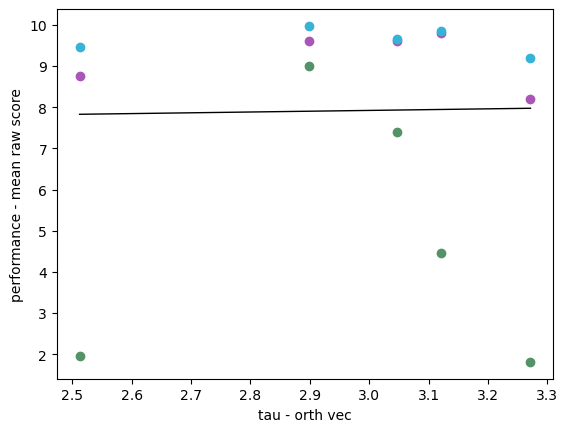

In [18]:
plt.figure()
#plt.scatter(mc_measures['orth_vec_thresh_crossed'], mean_raw_score_time_interval, c='b')
for i,trial in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        if mc_measures['tau_orth_vec'][i] > 15:
            plt.scatter(mc_measures['tau_orth_vec_not_norm'][i], mean_raw_score_time_interval[trial][seed], c=colors[j])
plt.xlabel('tau - orth vec')
plt.ylabel('performance - mean raw score')

# fit a linear regression
x, y = [], []
for i, trial in enumerate(weight_trials):
    if mc_measures['tau_orth_vec'][i] > 15:
        for seed in seeds:
            x.append(mc_measures['tau_orth_vec_not_norm'][i])
            y.append(mean_raw_score_time_interval[trial][seed])

x = np.asarray(x, float)
y = np.asarray(y, float)
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

reg = LinearRegression().fit(x.reshape(-1, 1), y)
x = np.linspace(x.min(), x.max(), 200)
plt.plot(x, reg.coef_[0]*x + reg.intercept_, color='black', linewidth=1)

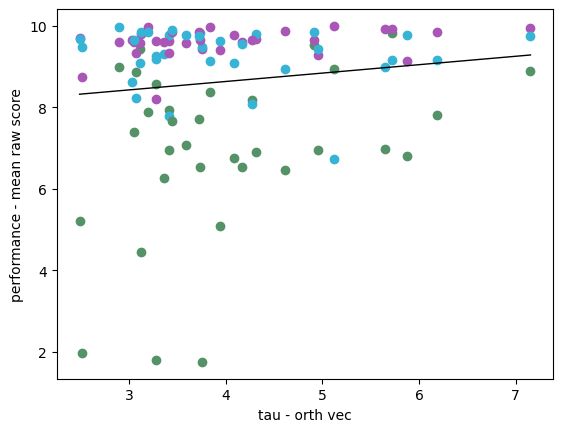

In [19]:
plt.figure()
#plt.scatter(mc_measures['orth_vec_thresh_crossed'], mean_raw_score_time_interval, c='b')
for i,trial in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        plt.scatter(mc_measures['tau_orth_vec_not_norm'][i], mean_raw_score_time_interval[trial][seed], c=colors[j])
plt.xlabel('tau - orth vec')
plt.ylabel('performance - mean raw score')

# fit a linear regression
x, y = [], []
for i, trial in enumerate(weight_trials):
    for seed in seeds:
        x.append(mc_measures['tau_orth_vec_not_norm'][i])
        y.append(mean_raw_score_time_interval[trial][seed])

x = np.asarray(x, float)
y = np.asarray(y, float)
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

reg = LinearRegression().fit(x.reshape(-1, 1), y)
x = np.linspace(x.min(), x.max(), 200)
plt.plot(x, reg.coef_[0]*x + reg.intercept_, color='black', linewidth=1)

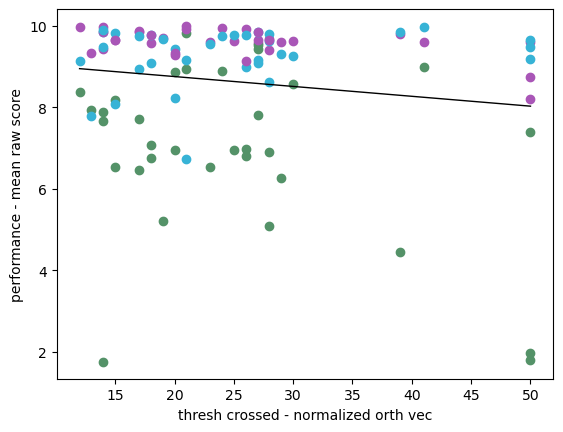

In [20]:
plt.figure()
#plt.scatter(mc_measures['orth_vec_thresh_crossed'], mean_raw_score_time_interval, c='b')
for i,trial in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        plt.scatter(mc_measures['orth_vec_thresh_crossed'][i], mean_raw_score_time_interval[trial][seed], c=colors[j])
plt.xlabel('thresh crossed - normalized orth vec')
plt.ylabel('performance - mean raw score')

# fit a linear regression
x, y = [], []
for i, trial in enumerate(weight_trials):
    for seed in seeds:
        x.append(mc_measures['orth_vec_thresh_crossed'][i])
        y.append(mean_raw_score_time_interval[trial][seed])

x = np.asarray(x, float)
y = np.asarray(y, float)
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

reg = LinearRegression().fit(x.reshape(-1, 1), y)
x = np.linspace(x.min(), x.max(), 200)
plt.plot(x, reg.coef_[0]*x + reg.intercept_, color='black', linewidth=1)

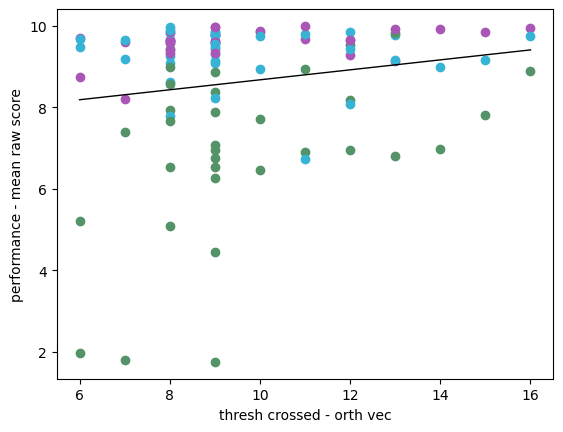

In [21]:
plt.figure()
#plt.scatter(mc_measures['orth_vec_thresh_crossed'], mean_raw_score_time_interval, c='b')
for i,trial in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        plt.scatter(mc_measures['orth_vec_thresh_crossed_not_norm'][i], mean_raw_score_time_interval[trial][seed], c=colors[j])
plt.xlabel('thresh crossed - orth vec')
plt.ylabel('performance - mean raw score')

# fit a linear regression
x, y = [], []
for i, trial in enumerate(weight_trials):
    for seed in seeds:
        x.append(mc_measures['orth_vec_thresh_crossed_not_norm'][i])
        y.append(mean_raw_score_time_interval[trial][seed])

x = np.asarray(x, float)
y = np.asarray(y, float)
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

reg = LinearRegression().fit(x.reshape(-1, 1), y)
x = np.linspace(x.min(), x.max(), 200)
plt.plot(x, reg.coef_[0]*x + reg.intercept_, color='black', linewidth=1)

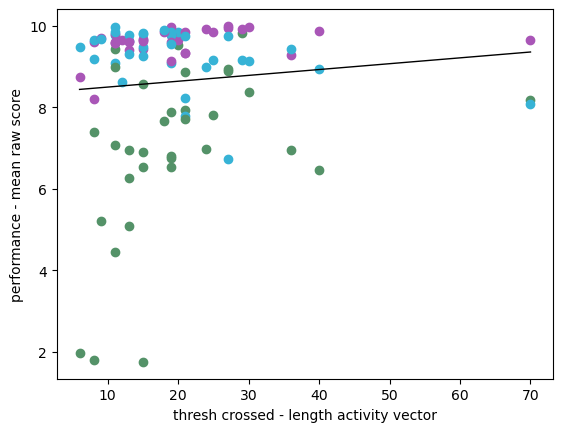

In [22]:
plt.figure()
#plt.scatter(mc_measures['orth_vec_thresh_crossed'], mean_raw_score_time_interval, c='b')
for i,trial in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        plt.scatter(mc_measures['norm_thresh_crossed'][i], mean_raw_score_time_interval[trial][seed], c=colors[j])
    #for policy in range(n_policies):
        #plt.scatter(mc_measures['norm_thresh_crossed'][2], mean_raw_score_time_interval[policy][2], c='r')
plt.xlabel('thresh crossed - length activity vector')
plt.ylabel('performance - mean raw score')

# fit a linear regression
x, y = [], []
for i, trial in enumerate(weight_trials):
    for seed in seeds:
        x.append(mc_measures['norm_thresh_crossed'][i])
        y.append(mean_raw_score_time_interval[trial][seed])

x = np.asarray(x, float)
y = np.asarray(y, float)
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

reg = LinearRegression().fit(x.reshape(-1, 1), y)
x = np.linspace(x.min(), x.max(), 200)
plt.plot(x, reg.coef_[0]*x + reg.intercept_, color='black', linewidth=1)

#### Giovanni et.al., SVD, participation ratio

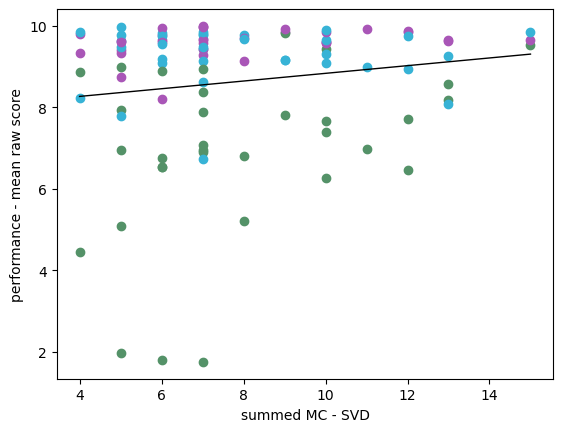

In [23]:
plt.figure()
#plt.scatter(mc_measures['orth_vec_thresh_crossed'], mean_raw_score_time_interval, c='b')
for i,trial in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        plt.scatter(mc_measures['summed_MC_svd'][i], mean_raw_score_time_interval[trial][seed], c=colors[j])
plt.xlabel('summed MC - SVD')
plt.ylabel('performance - mean raw score')

# fit a linear regression
x, y = [], []
for i, trial in enumerate(weight_trials):
    for seed in seeds:
        x.append(mc_measures['summed_MC_svd'][i])
        y.append(mean_raw_score_time_interval[trial][seed])

x = np.asarray(x, float)
y = np.asarray(y, float)
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

reg = LinearRegression().fit(x.reshape(-1, 1), y)
x = np.linspace(x.min(), x.max(), 200)
plt.plot(x, reg.coef_[0]*x + reg.intercept_, color='black', linewidth=1)

In [24]:
np.argmax(mc_measures['summed_MC_svd'])

np.int64(2)

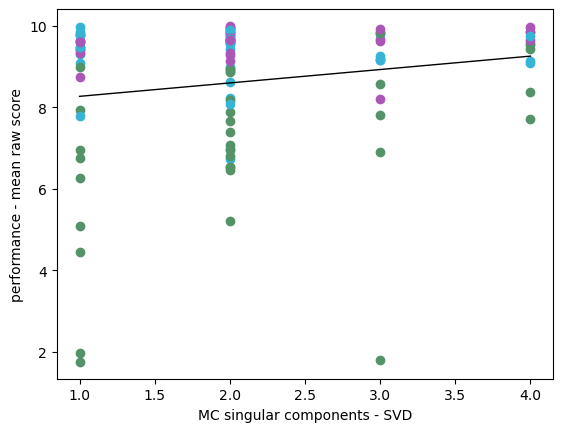

In [25]:
plt.figure()
#plt.scatter(mc_measures['orth_vec_thresh_crossed'], mean_raw_score_time_interval, c='b')
for i,trial in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        plt.scatter(mc_measures['MC_singular_components_svd'][i], mean_raw_score_time_interval[trial][seed], c=colors[j])
plt.xlabel('MC singular components - SVD')
plt.ylabel('performance - mean raw score')

# fit a linear regression
x, y = [], []
for i, trial in enumerate(weight_trials):
    for seed in seeds:
        x.append(mc_measures['MC_singular_components_svd'][i])
        y.append(mean_raw_score_time_interval[trial][seed])

x = np.asarray(x, float)
y = np.asarray(y, float)
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

reg = LinearRegression().fit(x.reshape(-1, 1), y)
x = np.linspace(x.min(), x.max(), 200)
plt.plot(x, reg.coef_[0]*x + reg.intercept_, color='black', linewidth=1)

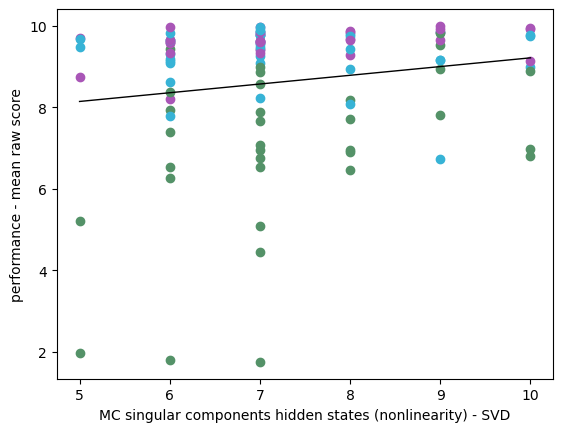

In [26]:
plt.figure()
#plt.scatter(mc_measures['orth_vec_thresh_crossed'], mean_raw_score_time_interval, c='b')
for i,trial in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        plt.scatter(mc_measures['MC_singular_components_hs_svd'][i], mean_raw_score_time_interval[trial][seed], c=colors[j])
plt.xlabel('MC singular components hidden states (nonlinearity) - SVD')
plt.ylabel('performance - mean raw score')

# fit a linear regression
x, y = [], []
for i, trial in enumerate(weight_trials):
    for seed in seeds:
        x.append(mc_measures['MC_singular_components_hs_svd'][i])
        y.append(mean_raw_score_time_interval[trial][seed])

x = np.asarray(x, float)
y = np.asarray(y, float)
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

reg = LinearRegression().fit(x.reshape(-1, 1), y)
x = np.linspace(x.min(), x.max(), 200)
plt.plot(x, reg.coef_[0]*x + reg.intercept_, color='black', linewidth=1)

TypeError: 'Axes' object is not subscriptable

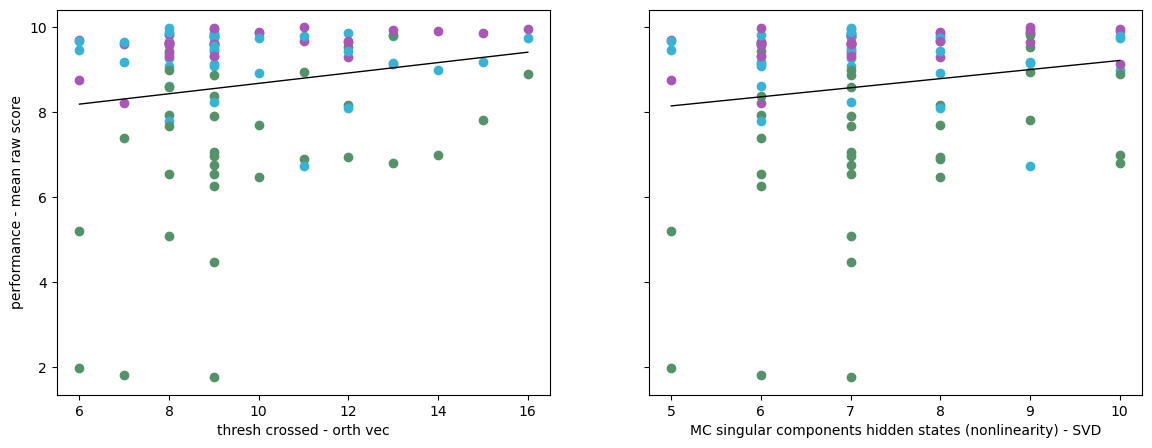

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

colors = ["#549268", '#a956b7', "#37B3D6"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# -------- Left plot: orth_vec_thresh_crossed_not_norm vs performance --------
ax = axes[0]
for i, trial in enumerate(weight_trials):
    for j, seed in enumerate(seeds):
        ax.scatter(
            mc_measures["orth_vec_thresh_crossed_not_norm"][i],
            mean_raw_score_time_interval[trial][seed],
            c=colors[j],

            label=f"seed {seed}"
        )

ax.set_xlabel("thresh crossed - orth vec")
ax.set_ylabel("performance - mean raw score")

# regression (left)
x, y = [], []
for i, trial in enumerate(weight_trials):
    for seed in seeds:
        x.append(mc_measures["orth_vec_thresh_crossed_not_norm"][i])
        y.append(mean_raw_score_time_interval[trial][seed])

x = np.asarray(x, float)
y = np.asarray(y, float)
m = np.isfinite(x) & np.isfinite(y)
x_fit, y_fit = x[m], y[m]

reg = LinearRegression().fit(x_fit.reshape(-1, 1), y_fit)
xx = np.linspace(x_fit.min(), x_fit.max(), 200)
ax.plot(xx, reg.coef_[0] * xx + reg.intercept_, color="black", linewidth=1)

# -------- Right plot: MC_singular_components_hs_svd vs performance --------
ax = axes[1]
for i, trial in enumerate(weight_trials):
    for j, seed in enumerate(seeds):
        ax.scatter(
            mc_measures["MC_singular_components_hs_svd"][i],
            mean_raw_score_time_interval[trial][seed],
            c=colors[j],
            label=f"seed {seed}"
        )

ax.set_xlabel("MC singular components hidden states (nonlinearity) - SVD")
ax.set_ylabel("")  # shared

# regression (right)
x, y = [], []
for i, trial in enumerate(weight_trials):
    for seed in seeds:
        x.append(mc_measures["MC_singular_components_hs_svd"][i])
        y.append(mean_raw_score_time_interval[trial][seed])

x = np.asarray(x, float)
y = np.asarray(y, float)
m = np.isfinite(x) & np.isfinite(y)
x_fit, y_fit = x[m], y[m]

reg = LinearRegression().fit(x_fit.reshape(-1, 1), y_fit)
xx = np.linspace(x_fit.min(), x_fit.max(), 200)
ax.plot(xx, reg.coef_[0] * xx + reg.intercept_, color="black", linewidth=1)

handles, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(seeds), frameon=False,
           bbox_to_anchor=(0.5, 0.995))

plt.tight_layout()
plt.show()


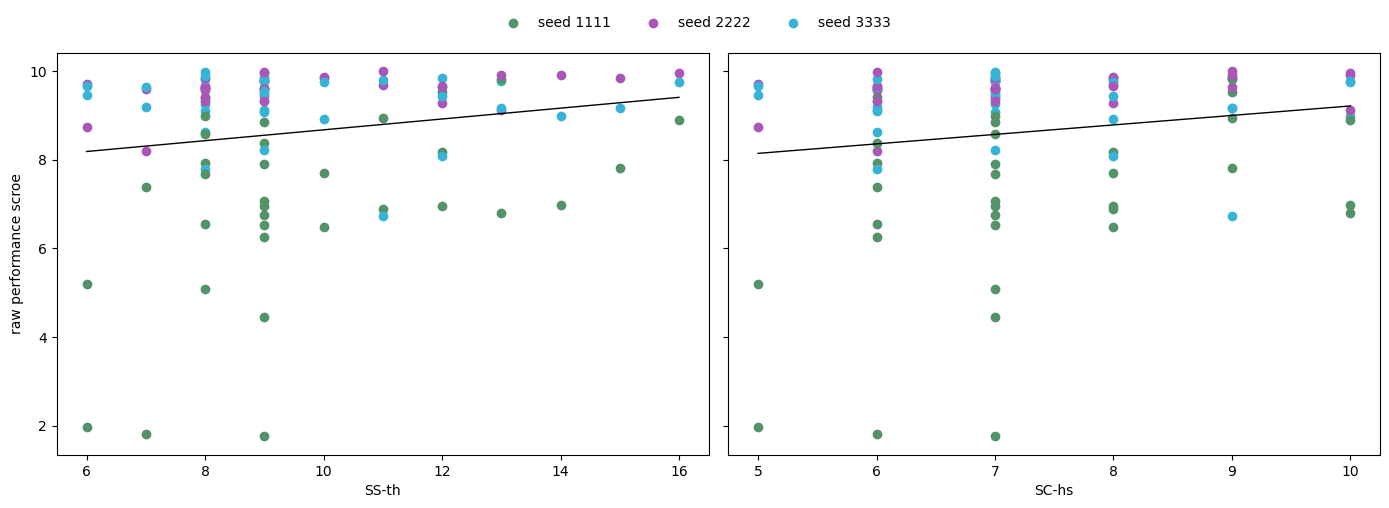

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

colors = ["#549268", "#a956b7", "#37B3D6"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# -------- Left plot --------
axL = axes[0]
for i, trial in enumerate(weight_trials):
    for j, seed in enumerate(seeds):
        axL.scatter(
            mc_measures["orth_vec_thresh_crossed_not_norm"][i],
            mean_raw_score_time_interval[trial][seed],
            c=colors[j],
            label=f"seed {seed}" if i == 0 else "_nolegend_"  # only label once per seed
        )

axL.set_xlabel("SS-th")
axL.set_ylabel("raw performance scroe")

# regression (left) — excluded from legend
x, y = [], []
for i, trial in enumerate(weight_trials):
    for seed in seeds:
        x.append(mc_measures["orth_vec_thresh_crossed_not_norm"][i])
        y.append(mean_raw_score_time_interval[trial][seed])

x = np.asarray(x, float)
y = np.asarray(y, float)
m = np.isfinite(x) & np.isfinite(y)
x_fit, y_fit = x[m], y[m]

reg = LinearRegression().fit(x_fit.reshape(-1, 1), y_fit)
xx = np.linspace(x_fit.min(), x_fit.max(), 200)
axL.plot(xx, reg.coef_[0] * xx + reg.intercept_, color="black", linewidth=1, label="_nolegend_")

# -------- Right plot --------
axR = axes[1]
for i, trial in enumerate(weight_trials):
    for j, seed in enumerate(seeds):
        axR.scatter(
            mc_measures["MC_singular_components_hs_svd"][i],
            mean_raw_score_time_interval[trial][seed],
            c=colors[j],
            label="_nolegend_"  # legend already handled via left plot
        )

axR.set_xlabel("SC-hs")

# regression (right) — excluded from legend
x, y = [], []
for i, trial in enumerate(weight_trials):
    for seed in seeds:
        x.append(mc_measures["MC_singular_components_hs_svd"][i])
        y.append(mean_raw_score_time_interval[trial][seed])

x = np.asarray(x, float)
y = np.asarray(y, float)
m = np.isfinite(x) & np.isfinite(y)
x_fit, y_fit = x[m], y[m]

reg = LinearRegression().fit(x_fit.reshape(-1, 1), y_fit)
xx = np.linspace(x_fit.min(), x_fit.max(), 200)
axR.plot(xx, reg.coef_[0] * xx + reg.intercept_, color="black", linewidth=1, label="_nolegend_")

# -------- Figure legend (seeds only) --------
handles, labels = axL.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(seeds), frameon=False,
           bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


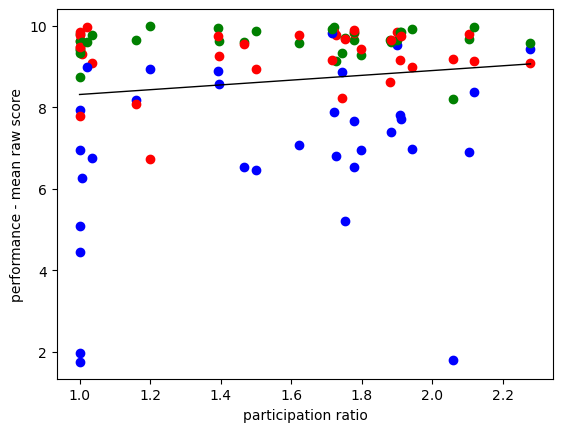

In [ ]:
plt.figure()
#plt.scatter(mc_measures['orth_vec_thresh_crossed'], mean_raw_score_time_interval, c='b')
for i,trial in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        plt.scatter(mc_measures['participation_ratio_svd'][i], mean_raw_score_time_interval[trial][seed], c=colors[j])
plt.xlabel('participation ratio')
plt.ylabel('performance - mean raw score')

# fit a linear regression
x, y = [], []
for i, trial in enumerate(weight_trials):
    for seed in seeds:
        x.append(mc_measures['participation_ratio_svd'][i])
        y.append(mean_raw_score_time_interval[trial][seed])

x = np.asarray(x, float)
y = np.asarray(y, float)
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

reg = LinearRegression().fit(x.reshape(-1, 1), y)
x = np.linspace(x.min(), x.max(), 200)
plt.plot(x, reg.coef_[0]*x + reg.intercept_, color='black', linewidth=1)

#### Corrrelation matrix

In [ ]:
# create the dataframe to perform the correlation operation on
mean_raw_score_across_seeds = []
for i,trial in enumerate(weight_trials):
    score = 0
    for seed in seeds:
        current_raw_score = mean_raw_score_time_interval[trial][seed]
        if np.isnan(current_raw_score):
            continue
        score += current_raw_score
    mean_raw_score_across_seeds.append(score / len(seeds))


In [ ]:
print(len(mean_raw_score_across_seeds))

34


In [ ]:
corr_df = pd.DataFrame({
    'performance': mean_raw_score_across_seeds,
    'AN': mc_measures['norm_thresh_crossed'],
    'SS-th': mc_measures['orth_vec_thresh_crossed_not_norm'],
    'SS-tau': mc_measures['tau_orth_vec_not_norm'],
    'nSS-th': mc_measures['orth_vec_thresh_crossed'],
    'nSS-tau': mc_measures['tau_orth_vec'],
    'OSM': mc_measures['summed_MC_svd'],
    'SC-k': mc_measures['MC_singular_components_svd'],
    'SC-hs': mc_measures['MC_singular_components_hs_svd'],
    'PR': mc_measures['participation_ratio_svd']
})

In [ ]:
corr_matrix = corr_df.corr()
print(corr_matrix)

                               raw performance score  activity norm  \
raw performance score                       1.000000       0.261569   
activity norm                               0.261569       1.000000   
subspace threshold                          0.411494       0.545734   
subspace tau                                0.350537       0.474406   
subspace normalized threshold              -0.322103      -0.489719   
subspace normalized tau                    -0.400968      -0.520914   
orthogonalize subspace method               0.338519       0.388823   
singular components krylov                  0.370402       0.147406   
singular components hs                      0.427559       0.462941   
participation ratio                         0.193002      -0.020631   

                               subspace threshold  subspace tau  \
raw performance score                    0.411494      0.350537   
activity norm                            0.545734      0.474406   
subspace threshol

In [ ]:
# compute significance for the correlations
def corr_pvalues_spearman(df):
    cols = df.columns
    n = len(cols)
    R = pd.DataFrame(np.eye(n), index=cols, columns=cols, dtype=float)
    P = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols, dtype=float)
    for i in range(n):
        for j in range(i+1, n):
            x = df.iloc[:, i]
            y = df.iloc[:, j]
            mask = x.notna() & y.notna()
            if mask.sum() < 3:
                r, p = np.nan, np.nan
            else:
                r, p = spearmanr(x[mask], y[mask])
            R.iat[i, j] = R.iat[j, i] = r
            P.iat[i, j] = P.iat[j, i] = p
    np.fill_diagonal(P.values, 0.0)
    return R, P

In [ ]:
R, P = corr_pvalues_spearman(corr_df)

# Multiple-comparison correction (recommended for many cells)
# We'll FDR-correct all upper-triangle p-values.
pvals = P.values[np.triu_indices_from(P.values, k=1)]
reject, pvals_fdr, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")

P_fdr = P.copy()
P_fdr.values[np.triu_indices_from(P.values, k=1)] = pvals_fdr
P_fdr.values[(np.triu_indices_from(P.values, k=1)[1],
              np.triu_indices_from(P.values, k=1)[0])] = pvals_fdr  # mirror


In [ ]:
def p_to_stars(p):
    if np.isnan(p): return ""
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

stars = P_fdr.applymap(p_to_stars)

/tmp/ipykernel_2106857/3066172316.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  stars = P_fdr.applymap(p_to_stars)


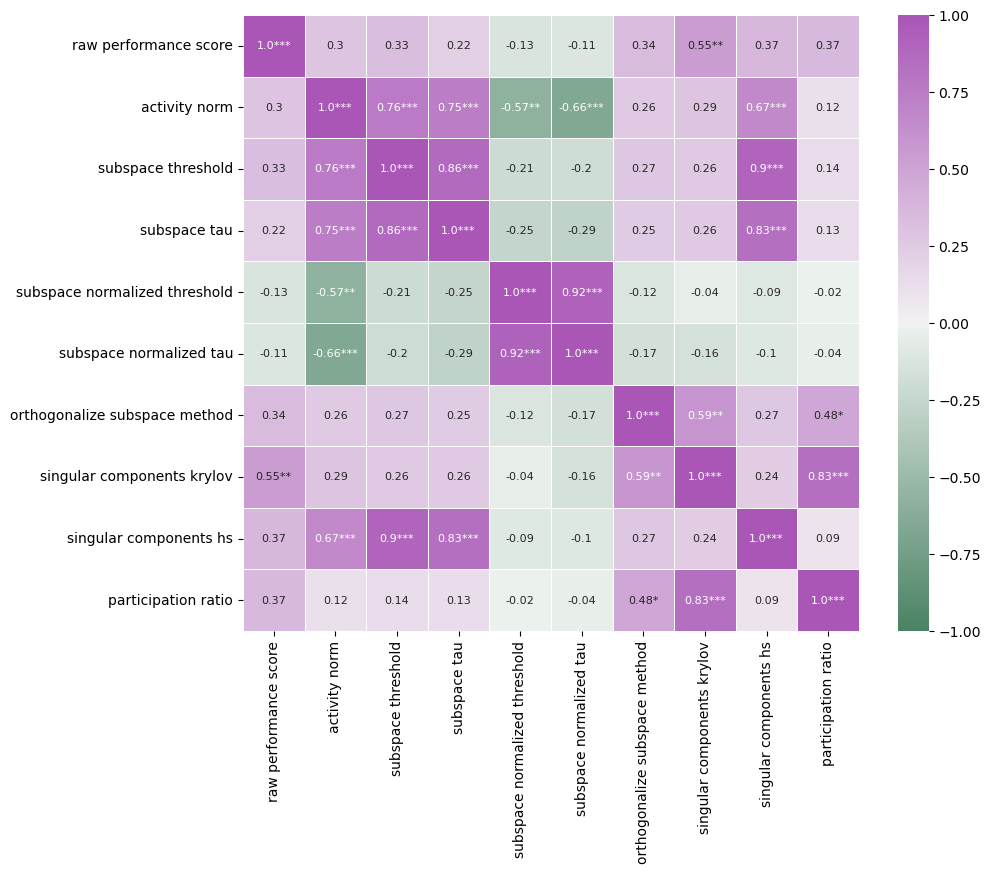

In [ ]:
annot = R.round(2).astype(str) + stars

plt.figure(figsize=(10, 8))
sns.heatmap(R, vmin=-1, vmax=1, center=0, square=True,
            annot=annot, fmt="", linewidths=0.5, cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True), annot_kws={"size":8, "va":"center"})
#plt.title("Correlation matrix (Pearson r) with FDR-significance stars")
plt.savefig('/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/figures/corr_matrix_significance.png')
plt.show()

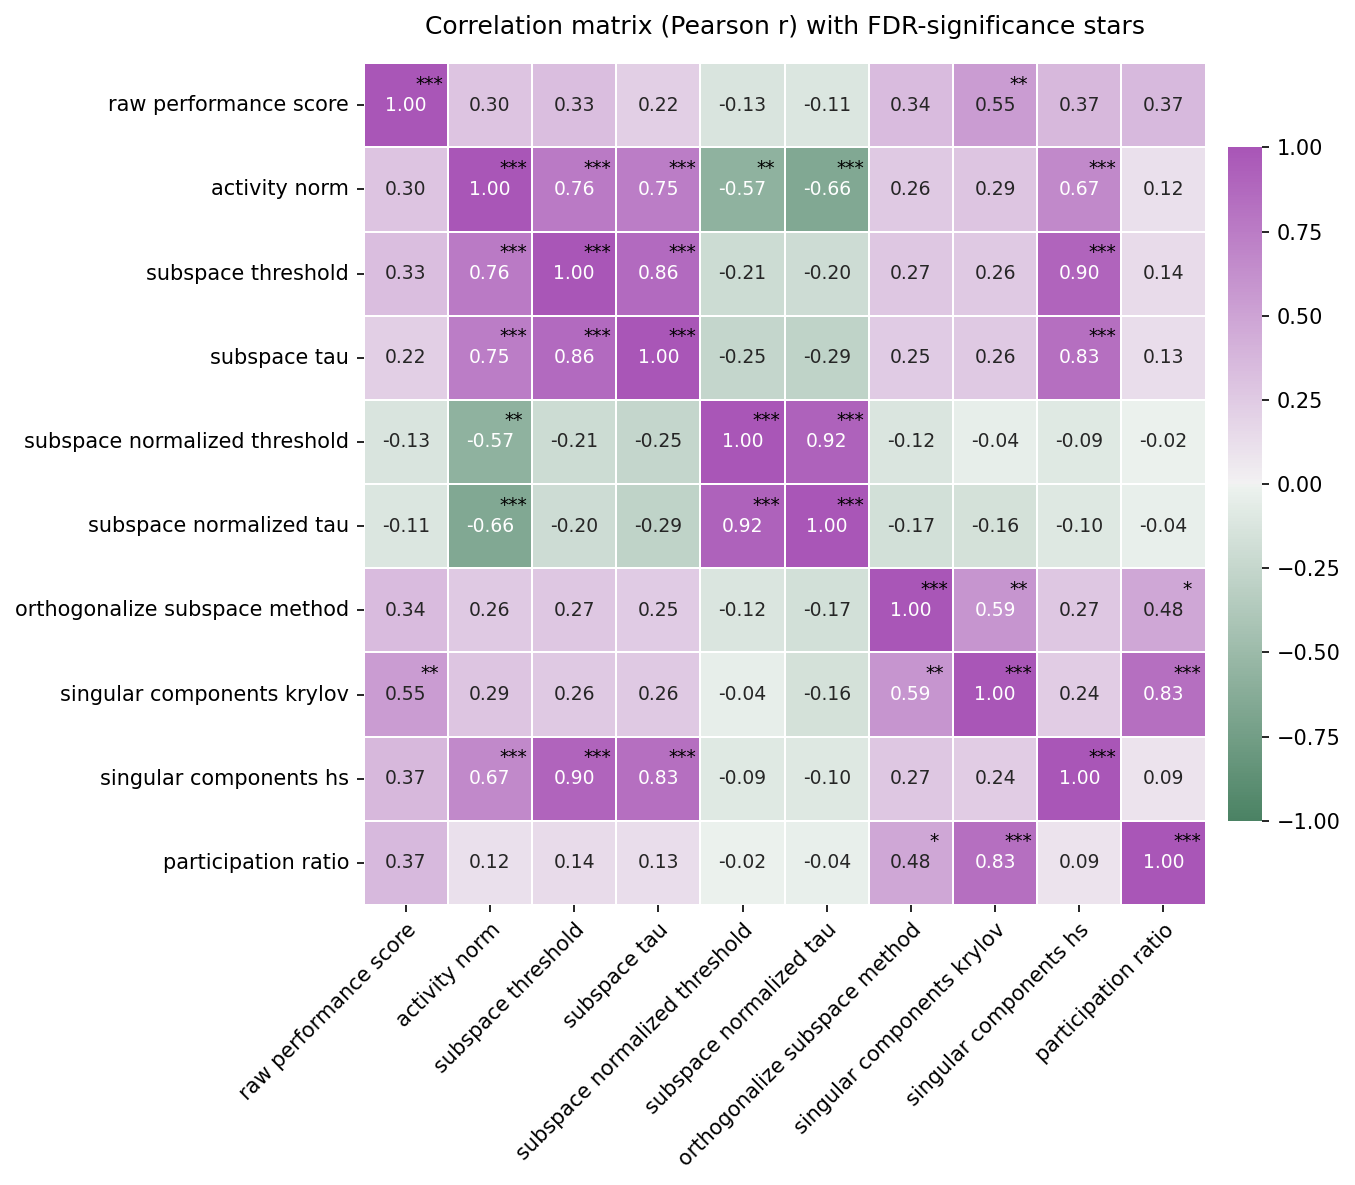

In [ ]:

plt.figure(figsize=(10, 8), dpi=150)
ax = sns.heatmap(
    R,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True),
    square=True,
    linewidths=0.8, linecolor="white",
    annot=R.round(2), fmt=".2f",
    annot_kws={"size":9},
    cbar_kws={"shrink": 0.8, "pad": 0.02}
)

# overlay stars as separate text (top-right corner of each cell)
for i in range(R.shape[0]):
    for j in range(R.shape[1]):
        s = stars.iat[i, j]
        if s != "":
            ax.text(j + 0.78, i + 0.25, s, ha="center", va="center", fontsize=9)

ax.set_title("Correlation matrix (Pearson r) with FDR-significance stars", pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()



#### Pearson correlation to compare

/tmp/ipykernel_2106857/1117105677.py:46: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  stars = P_fdr.applymap(p_to_stars)


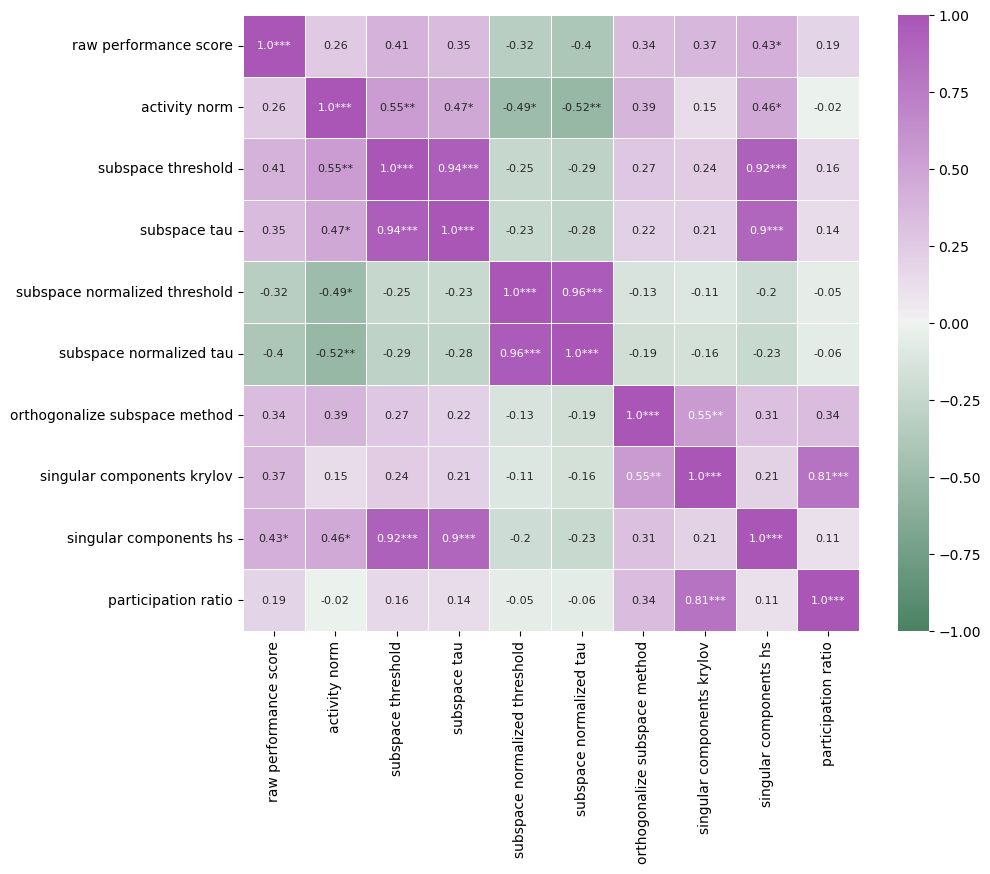

In [ ]:

def corr_pvalues(df, method="pearson"):
    cols = df.columns
    n = len(cols)
    R = pd.DataFrame(np.eye(n), index=cols, columns=cols, dtype=float)
    P = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols, dtype=float)

    for i in range(n):
        for j in range(i+1, n):
            x = df.iloc[:, i]
            y = df.iloc[:, j]
            mask = x.notna() & y.notna()
            if mask.sum() < 3:
                r, p = np.nan, np.nan
            else:
                if method == "pearson":
                    r, p = pearsonr(x[mask], y[mask])
                elif method == "spearman":
                    r, p = pd.Series(x[mask]).corr(pd.Series(y[mask]), method="spearman"), \
                           pd.Series(x[mask]).corr(pd.Series(y[mask]), method="spearman")  # placeholder
                    # Better: use scipy.stats.spearmanr for p-values
                else:
                    raise ValueError("method must be 'pearson' or 'spearman'")

            R.iat[i, j] = R.iat[j, i] = r
            P.iat[i, j] = P.iat[j, i] = p

    np.fill_diagonal(P.values, 0.0)
    return R, P

R, P = corr_pvalues(corr_df, method="pearson") 
pvals = P.values[np.triu_indices_from(P.values, k=1)]
reject, pvals_fdr, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")

P_fdr = P.copy()
P_fdr.values[np.triu_indices_from(P.values, k=1)] = pvals_fdr
P_fdr.values[(np.triu_indices_from(P.values, k=1)[1],
              np.triu_indices_from(P.values, k=1)[0])] = pvals_fdr

def p_to_stars(p):
    if np.isnan(p): return ""
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

stars = P_fdr.applymap(p_to_stars)
annot = R.round(2).astype(str) + stars

plt.figure(plt.figure(figsize=(10, 8)))
sns.heatmap(R, vmin=-1, vmax=1, center=0, square=True,
            annot=annot, fmt="", linewidths=0.5, cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True), annot_kws={"size":8, "va":"center"})
#plt.title("Correlation matrix (Pearson r) with FDR-significance stars")
plt.show()

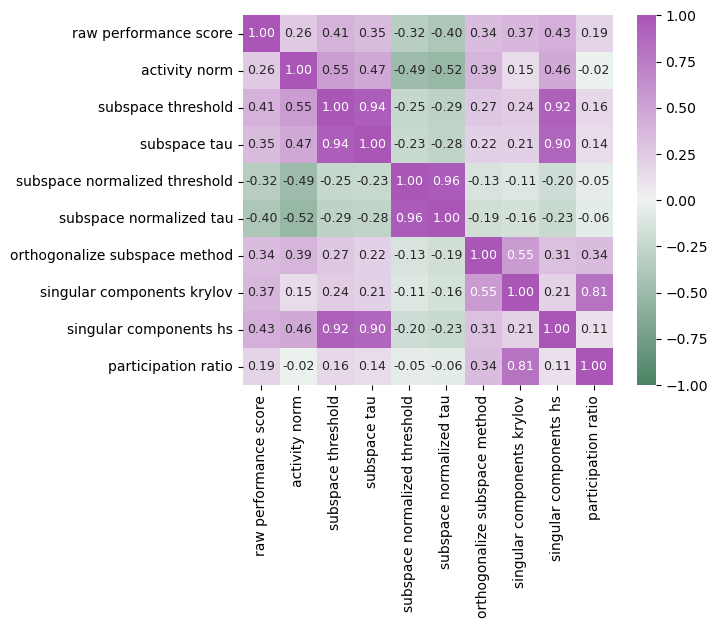

In [ ]:
axis_corr = sns.heatmap(corr_matrix,vmin=-1, vmax=1, center=0,cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True),square=True, annot=True, fmt=".2f", annot_kws={"size":9})

plt.show()

In [ ]:
import numpy as np

print("corr_df shape:", corr_df.shape)        # should be (34, 10) (or similar)
corr_matrix = corr_df.corr()
print("corr_matrix shape:", corr_matrix.shape) # should be (10, 10)

# IMPORTANT: pass corr_df (raw), NOT corr_matrix, into your p-value function
R, P = corr_pvalues_spearman(corr_df)

# They should match numerically:
print("max abs diff:", np.nanmax(np.abs(R.values - corr_matrix.values)))


corr_df shape: (34, 10)
corr_matrix shape: (10, 10)
max abs diff: 0.28897366763993876


In [ ]:
# do the same again but exclude the seed with the bad performance
new_seeds = [3333]

# create the dataframe to perform the correlation operation on
new_mean_raw_score_across_seeds = []
for i,trial in enumerate(weight_trials):
    score = 0
    for seed in new_seeds:
        score += mean_raw_score_time_interval[trial][seed]
    new_mean_raw_score_across_seeds.append(score / len(new_seeds))

In [ ]:
new_corr_df = pd.DataFrame({
    'mean_raw_score': new_mean_raw_score_across_seeds,
    'orth_vec_thresh_crossed': mc_measures['orth_vec_thresh_crossed'],
    'orth_vec_thresh_crossed_not_norm': mc_measures['orth_vec_thresh_crossed_not_norm'],
    'norm_thresh_crossed': mc_measures['norm_thresh_crossed'],
    'tau_orth_vec': mc_measures['tau_orth_vec'],
    'tau_orth_vec_not_norm': mc_measures['tau_orth_vec_not_norm'],
    'summed_MC_svd': mc_measures['summed_MC_svd'],
    'MC_singular_components_svd': mc_measures['MC_singular_components_svd'],
    'MC_singular_components_hs_svd': mc_measures['MC_singular_components_hs_svd'],
    'participation_ratio_svd': mc_measures['participation_ratio_svd']
})

In [ ]:
new_corr_matrix = new_corr_df.corr()


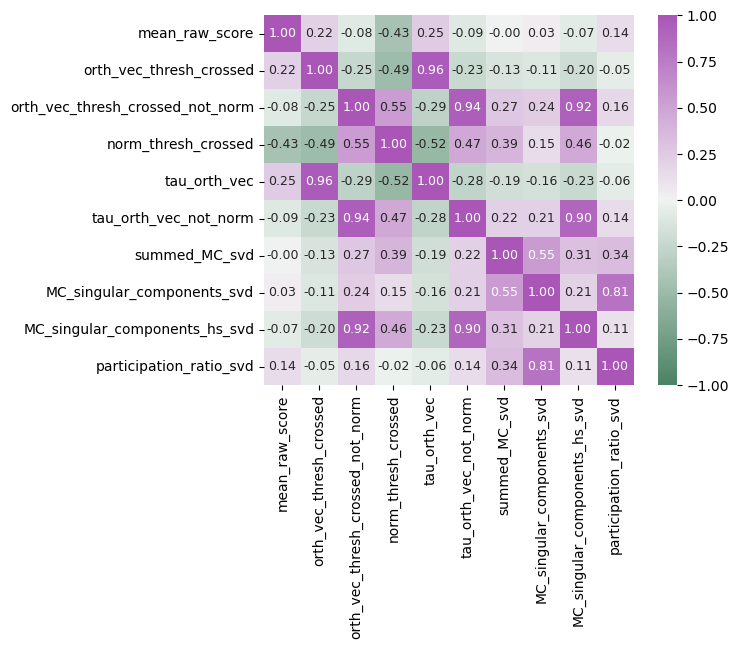

In [ ]:
axis_corr = sns.heatmap(new_corr_matrix,vmin=-1, vmax=1, center=0,cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True),square=True, annot=True, fmt=".2f", annot_kws={"size":9})

plt.show()

#### Multivariate Regression

In [ ]:
X.shape

NameError: name 'X' is not defined

In [ ]:
# y: target
y = corr_df['raw performance score'].to_numpy()

# X: predictors
X = corr_df.drop(columns=['raw performance score'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

pipe = Pipeline([('z-score', StandardScaler()), ('linear-regression', LinearRegression())])

pipe.fit(X_train, y_train)

y_prediction = pipe.predict(X_test)

print("R^2 (test):", r2_score(y_test, y_prediction))
#print("RMSE (test):", mean_squared_error(y_test, y_prediction, squared=False)) 

R^2 (test): -3.436859030927881


In [ ]:
beta = pipe.named_steps['linear-regression'].coef_
coef_table = (
    X.columns.to_frame(index=False, name='predictor')
    .assign(beta=beta)
    .sort_values('beta', key=lambda s: np.abs(s), ascending=False)
)
print(coef_table)

                          predictor      beta
3                      tau_orth_vec  1.342803
0           orth_vec_thresh_crossed -1.156819
6        MC_singular_components_svd  0.895390
4             tau_orth_vec_not_norm  0.759527
1  orth_vec_thresh_crossed_not_norm -0.527275
8           participation_ratio_svd -0.322777
2               norm_thresh_crossed  0.258665
5                     summed_MC_svd -0.154928
7     MC_singular_components_hs_svd -0.129897


In [ ]:
ridge_pipeline = Pipeline([('z-score', StandardScaler()),('ridge', Ridge(alpha=1))])

ridge_pipeline.fit(X_train, y_train)
y_prediction_ridge = ridge_pipeline.predict(X_test)

print("R^2 (test):", r2_score(y_test, y_prediction_ridge))

R^2 (test): -0.5266369292736968


In [ ]:
beta = ridge_pipeline.named_steps['ridge'].coef_
coef_table = (
    X.columns.to_frame(index=False, name='predictor')
    .assign(beta=beta)
    .sort_values('beta', key=lambda s: np.abs(s), ascending=False)
)
print(coef_table)

                          predictor      beta
6        MC_singular_components_svd  0.489162
3                      tau_orth_vec  0.391897
0           orth_vec_thresh_crossed -0.329124
4             tau_orth_vec_not_norm  0.191931
8           participation_ratio_svd -0.152353
1  orth_vec_thresh_crossed_not_norm -0.089952
7     MC_singular_components_hs_svd  0.078135
2               norm_thresh_crossed  0.053651
5                     summed_MC_svd -0.028319


In [ ]:
corr_df_regression = pd.DataFrame({
    'raw performance score': mean_raw_score_across_seeds,
    'subspace threshold': mc_measures['orth_vec_thresh_crossed_not_norm'],
    'subspace normalized tau': mc_measures['tau_orth_vec'],
    'singular components krylov': mc_measures['MC_singular_components_svd']
})

In [ ]:
# y: target
y = corr_df_regression['raw performance score'].to_numpy()

# X: predictors
X = corr_df_regression.drop(columns=['raw performance score'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

for i in np.logspace(0,2, 20):
    print(i)
    ridge_pipeline = Pipeline([('z-score', StandardScaler()),('ridge', Ridge(alpha=i))])

    ridge_pipeline.fit(X_train, y_train)
    y_prediction_ridge = ridge_pipeline.predict(X_test)

    print("R^2 (test):", r2_score(y_test, y_prediction_ridge))
    beta = ridge_pipeline.named_steps['ridge'].coef_
    coef_table = (
        X.columns.to_frame(index=False, name='predictor')
        .assign(beta=beta)
        .sort_values('beta', key=lambda s: np.abs(s), ascending=False)
    )
    #print(coef_table)

1.0
R^2 (test): 0.03856485681052979
1.2742749857031337
R^2 (test): 0.0413598039190447
1.6237767391887217
R^2 (test): 0.04476130086762209
2.0691380811147897
R^2 (test): 0.04885024730710252
2.636650898730358
R^2 (test): 0.05368954724502695
3.3598182862837818
R^2 (test): 0.05930508100411802
4.281332398719393
R^2 (test): 0.06566053333231847
5.455594781168519
R^2 (test): 0.07262790420930809
6.951927961775605
R^2 (test): 0.07995867304741267
8.858667904100825
R^2 (test): 0.08726445811468453
11.28837891684689
R^2 (test): 0.09401910962018789
14.38449888287663
R^2 (test): 0.09959393603629463
18.329807108324356
R^2 (test): 0.10333157026576689
23.357214690901213
R^2 (test): 0.10465130835130942
29.763514416313175
R^2 (test): 0.10316330087680448
37.926901907322495
R^2 (test): 0.0987584890022074
48.32930238571752
R^2 (test): 0.09164343874948344
61.584821106602604
R^2 (test): 0.08230610741846534
78.47599703514611
R^2 (test): 0.07142302103630971
100.0
R^2 (test): 0.05973800045271693


In [ ]:
ridge_pipeline = Pipeline([('z-score', StandardScaler()),('ridge', Ridge(alpha=25))])

ridge_pipeline.fit(X_train, y_train)
y_prediction_ridge = ridge_pipeline.predict(X_test)
print("R^2 (test):", r2_score(y_test, y_prediction_ridge))
beta = ridge_pipeline.named_steps['ridge'].coef_
coef_table = (
    X.columns.to_frame(index=False, name='predictor')
    .assign(beta=beta)
    .sort_values('beta', key=lambda s: np.abs(s), ascending=False)
)
print(coef_table)

R^2 (test): 0.10452775613912124
                    predictor      beta
2  singular components krylov  0.167382
0          subspace threshold  0.107425
1     subspace normalized tau  0.001302


In [ ]:
# y: target
y = corr_df['raw performance score'].to_numpy()

# X: predictors
X = corr_df.drop(columns=['raw performance score'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

for i in np.logspace(0,2, 20):
    print(i)
    ridge_pipeline = Pipeline([('z-score', StandardScaler()),('ridge', Ridge(alpha=i))])

    ridge_pipeline.fit(X_train, y_train)
    y_prediction_ridge = ridge_pipeline.predict(X_test)

    print("R^2 (test):", r2_score(y_test, y_prediction_ridge))
    beta = ridge_pipeline.named_steps['ridge'].coef_
    coef_table = (
        X.columns.to_frame(index=False, name='predictor')
        .assign(beta=beta)
        .sort_values('beta', key=lambda s: np.abs(s), ascending=False)
    )
    #print(coef_table)

1.0
R^2 (test): -0.5266369292736961
1.2742749857031337
R^2 (test): -0.3898573722144272
1.6237767391887217
R^2 (test): -0.27509206054892865
2.0691380811147897
R^2 (test): -0.1804373128263539
2.636650898730358
R^2 (test): -0.10349523872284316
3.3598182862837818
R^2 (test): -0.04173102352918345
4.281332398719393
R^2 (test): 0.007295640722404295
5.455594781168519
R^2 (test): 0.04580375725056818
6.951927961775605
R^2 (test): 0.07573431868363956
8.858667904100825
R^2 (test): 0.09873181731185343
11.28837891684689
R^2 (test): 0.11614226383122139
14.38449888287663
R^2 (test): 0.1290174869234222
18.329807108324356
R^2 (test): 0.1381248405071629
23.357214690901213
R^2 (test): 0.14396733317394517
29.763514416313175
R^2 (test): 0.14682133358764005
37.926901907322495
R^2 (test): 0.1467972419628112
48.32930238571752
R^2 (test): 0.14392267365149514
61.584821106602604
R^2 (test): 0.13823856520515332
78.47599703514611
R^2 (test): 0.1298892578270966
100.0
R^2 (test): 0.11918321289116163


In [ ]:
ridge_pipeline = Pipeline([('z-score', StandardScaler()),('ridge', Ridge(alpha=25))])

ridge_pipeline.fit(X_train, y_train)
y_prediction_ridge = ridge_pipeline.predict(X_test)
print("R^2 (test):", r2_score(y_test, y_prediction_ridge))
beta = ridge_pipeline.named_steps['ridge'].coef_
coef_table = (
    X.columns.to_frame(index=False, name='predictor')
    .assign(beta=beta)
    .sort_values('beta', key=lambda s: np.abs(s), ascending=False)
)
print(coef_table)

R^2 (test): 0.14506200149615078
                       predictor      beta
6     singular components krylov  0.136507
7         singular components hs  0.068994
2                   subspace tau  0.052042
1             subspace threshold  0.045803
5  orthogonalize subspace method  0.042659
8            participation ratio  0.033743
4        subspace normalized tau  0.012772
0                  activity norm  0.008824
3  subspace normalized threshold -0.008707
